In [2]:
import pandas as pd

# Load data
df = pd.read_csv(r"C:\Users\SUSANTA\Desktop\future intern\Churn_Modelling.csv")

print(df.head())
print(df.info())
print(df['Exited'].value_counts())


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [3]:
import sys  
print(sys.executable)  


C:\Users\SUSANTA\anaconda3\python.exe


In [4]:
!pip install xgboost


C:\Users\SUSANTA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:22:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


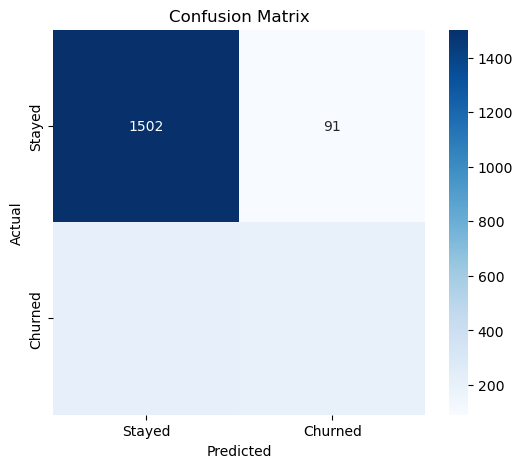

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.68      0.48      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000

ROC AUC Score: 0.8328343752072566


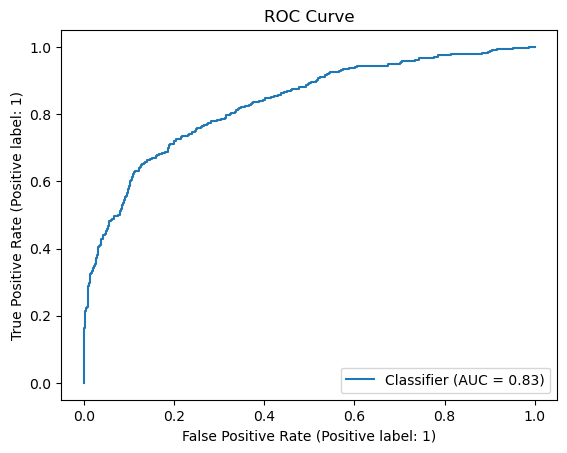

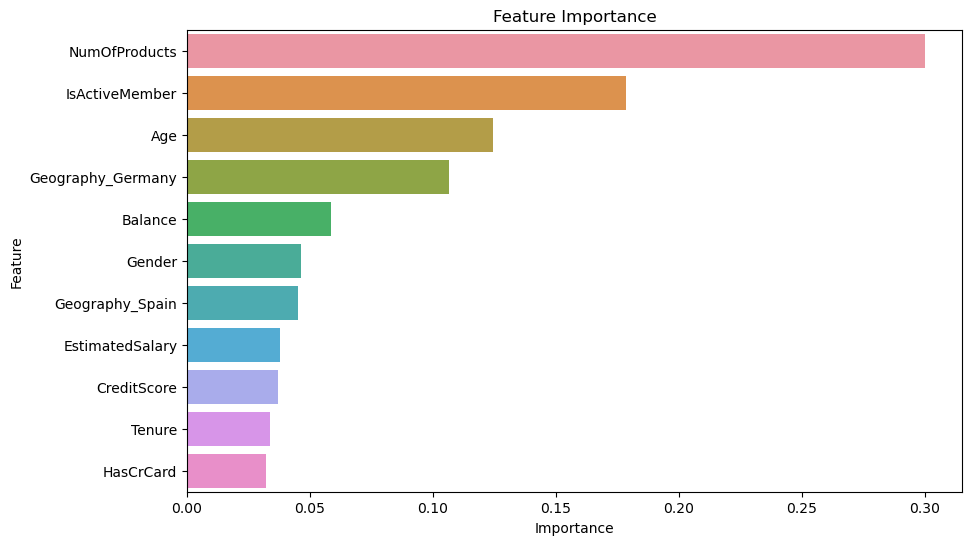

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Users\SUSANTA\Desktop\future intern\Churn_Modelling.csv")

# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical variables
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Define features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split data with stratification on target label
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train XGBoost classifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Predict on test
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report and ROC AUC score
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Plot ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve')
plt.show()

# Feature importance visualization
importance = model.feature_importances_
features = X.columns
fi_df = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=fi_df)
plt.title('Feature Importance')
plt.show()


In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_resampled.value_counts())


Before SMOTE: Exited
0    6370
1    1630
Name: count, dtype: int64
After SMOTE: Exited
1    6370
0    6370
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
rand_search = RandomizedSearchCV(xgb, param_grid, n_iter=10, scoring='roc_auc', cv=3, random_state=42, n_jobs=-1)
rand_search.fit(X_resampled, y_resampled)

print("Best Parameters:", rand_search.best_params_)

# Use best estimator for predictions
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


C:\Users\SUSANTA\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [10:31:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}


In [17]:

results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Churn_Probability'] = y_proba
results.to_csv('bank_churn_results.csv', index=False)


C:\Users\SUSANTA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


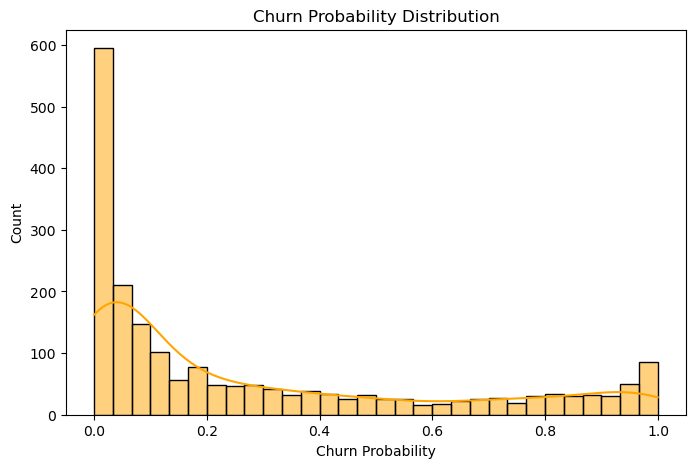

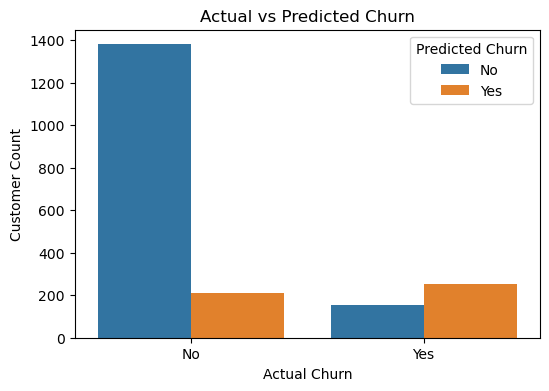

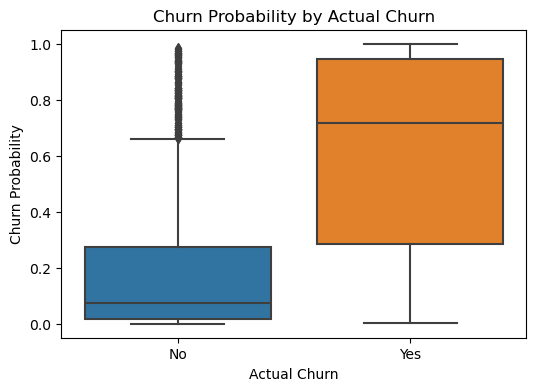

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the exported results file
results = pd.read_csv('bank_churn_results.csv')

# Map numeric churn values to string labels
mapping = {0: 'No', 1: 'Yes'}
results['Actual'] = results['Actual'].map(mapping).astype(str)
results['Predicted'] = results['Predicted'].map(mapping).astype(str)

# Distribution of churn probabilities
plt.figure(figsize=(8,5))
sns.histplot(results['Churn_Probability'], bins=30, kde=True, color='orange')
plt.title('Churn Probability Distribution')
plt.xlabel('Churn Probability')
plt.ylabel('Count')
plt.show()

# Compare actual vs predicted churn
plt.figure(figsize=(6,4))
sns.countplot(x='Actual', hue='Predicted', data=results)
plt.title('Actual vs Predicted Churn')
plt.xlabel('Actual Churn')
plt.ylabel('Customer Count')
plt.legend(title='Predicted Churn')
plt.show()

# Boxplot of Probability by Actual Churn (to understand probability separation)
plt.figure(figsize=(6,4))
sns.boxplot(x='Actual', y='Churn_Probability', data=results)
plt.title('Churn Probability by Actual Churn')
plt.xlabel('Actual Churn')
plt.ylabel('Churn Probability')
plt.show()


In [19]:
# 1. Count correct and incorrect predictions
correct = (results['Actual'] == results['Predicted']).sum()
incorrect = (results['Actual'] != results['Predicted']).sum()
print(f"Correct predictions: {correct}")
print(f"Incorrect predictions: {incorrect}")

# 2. Average churn probability by actual churn group
avg_prob = results.groupby('Actual')['Churn_Probability'].mean()
print("Average Churn Probability by Actual Outcome:")
print(avg_prob)

# 3. Classification report using churn probability threshold (e.g., 0.5)
threshold = 0.5
results['Predicted_Prob_Label'] = (results['Churn_Probability'] > threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report (Threshold = 0.5):")
print(classification_report(results['Actual'], results['Predicted_Prob_Label']))

cm = confusion_matrix(results['Actual'], results['Predicted_Prob_Label'])
print("Confusion Matrix (Threshold = 0.5):")
print(cm)


Correct predictions: 1635
Incorrect predictions: 365
Average Churn Probability by Actual Outcome:
Actual
0    0.191663
1    0.612435
Name: Churn_Probability, dtype: float64
Classification Report (Threshold = 0.5):
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1593
           1       0.55      0.62      0.58       407

    accuracy                           0.82      2000
   macro avg       0.72      0.75      0.73      2000
weighted avg       0.83      0.82      0.82      2000

Confusion Matrix (Threshold = 0.5):
[[1381  212]
 [ 153  254]]


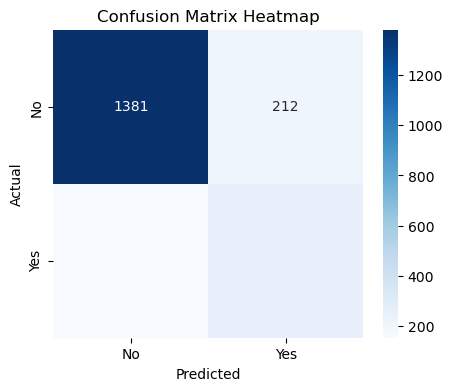

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Add the predicted label column based on threshold
threshold = 0.5
results['Predicted_Prob_Label'] = (results['Churn_Probability'] > threshold).astype(int)

# Convert Actual column from 'No'/'Yes' to binary 0/1
results['Actual_Binary'] = results['Actual'].map({'No': 0, 'Yes': 1})

# Generate confusion matrix with matching binary columns
cm = confusion_matrix(results['Actual_Binary'], results['Predicted_Prob_Label'])

# Plot the confusion matrix heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix Heatmap')
plt.show()


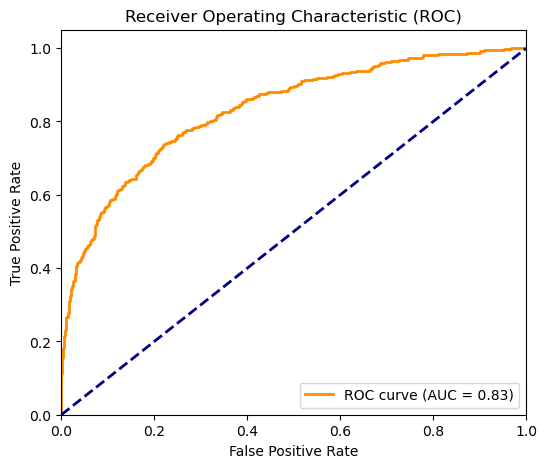

In [5]:
from sklearn.metrics import roc_curve, auc

# Map Actual labels back to binary for ROC/AUC
actual_binary = results['Actual'].map({'No': 0, 'Yes': 1})

fpr, tpr, thresholds = roc_curve(actual_binary, results['Churn_Probability'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision = precision_score(actual_binary, results['Predicted_Prob_Label'])
recall = recall_score(actual_binary, results['Predicted_Prob_Label'])
f1 = f1_score(actual_binary, results['Predicted_Prob_Label'])
accuracy = accuracy_score(actual_binary, results['Predicted_Prob_Label'])

print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')


Accuracy: 0.818
Precision: 0.545
Recall: 0.624
F1 Score: 0.582


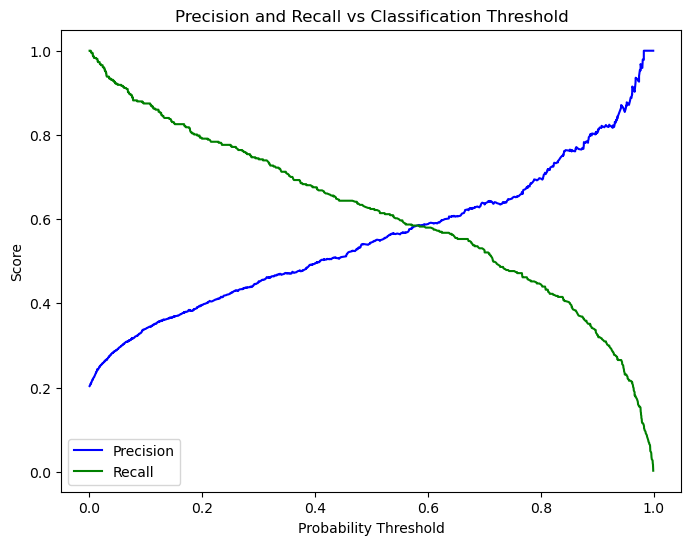

In [7]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(results['Actual_Binary'], results['Churn_Probability'])

plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label='Precision', color='b')
plt.plot(thresholds, recall[:-1], label='Recall', color='g')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Classification Threshold')
plt.legend()
plt.show()


In [8]:
import numpy as np

# Calculate F1 scores for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Find the index of the maximum F1 score
best_index = np.argmax(f1_scores)

# Get the threshold corresponding to the best F1 score
best_threshold = thresholds[best_index]

print(f'Best threshold based on max F1 score: {best_threshold:.3f}')
print(f'Precision at best threshold: {precision[best_index]:.3f}')
print(f'Recall at best threshold: {recall[best_index]:.3f}')
print(f'F1 score at best threshold: {f1_scores[best_index]:.3f}')


Best threshold based on max F1 score: 0.538
Precision at best threshold: 0.566
Recall at best threshold: 0.609
F1 score at best threshold: 0.587


              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1593
           1       0.57      0.61      0.59       407

    accuracy                           0.82      2000
   macro avg       0.73      0.74      0.74      2000
weighted avg       0.83      0.82      0.83      2000



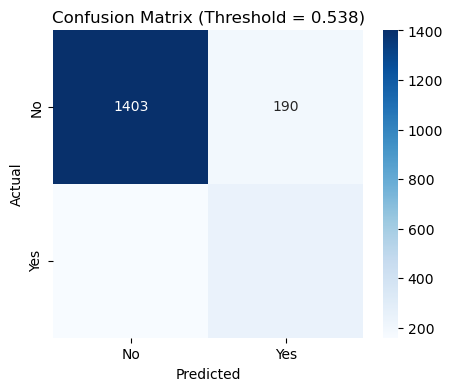

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create new predicted labels using the best threshold
results['New_Prediction'] = (results['Churn_Probability'] > best_threshold).astype(int)

# Classification report
print(classification_report(results['Actual_Binary'], results['New_Prediction']))

# Confusion matrix
cm = confusion_matrix(results['Actual_Binary'], results['New_Prediction'])

# Plot confusion matrix heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.show()


In [10]:
# False positives: predicted churn but actual no churn
false_positives = results[(results['New_Prediction'] == 1) & (results['Actual_Binary'] == 0)]

# False negatives: predicted no churn but actual churn
false_negatives = results[(results['New_Prediction'] == 0) & (results['Actual_Binary'] == 1)]

print(f'Number of false positives: {false_positives.shape[0]}')
print(f'Number of false negatives: {false_negatives.shape[0]}')

# Optional: preview some false positives and false negatives
print('\nSample False Positives:')
print(false_positives.head())

print('\nSample False Negatives:')
print(false_negatives.head())


Number of false positives: 190
Number of false negatives: 160

Sample False Positives:
    CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
5           559       1   34       0       0.00              1          1   
7           706       0   29       6  185544.36              1          1   
8           505       1   49       7   80001.23              1          0   
11          625       0   38       7       0.00              1          1   
19          572       0   35       1  139979.07              1          1   

    IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
5                0        182988.94              False             True   
7                0        171037.63               True            False   
8                0        135180.11              False            False   
11               0        164804.02              False            False   
19               0        185662.84               True            False   


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Example: assume 'model' is your trained model and 'X' your feature DataFrame
feature_importances = model.feature_importances_
feature_names = X.columns

# Create DataFrame for plotting
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # Highest importance on top
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()


NameError: name 'model' is not defined

In [13]:
# Assuming 'Actual_Binary' is the target column
# Exclude non-feature columns from X
feature_columns = [col for col in results.columns if col not in ['Actual', 'Actual_Binary', 'Predicted', 'Predicted_Prob_Label', 'New_Prediction', 'Churn_Probability']]

# Define feature matrix and target vector
X = results[feature_columns]
y = results['Actual_Binary']

print('Features used for training:', feature_columns)


Features used for training: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


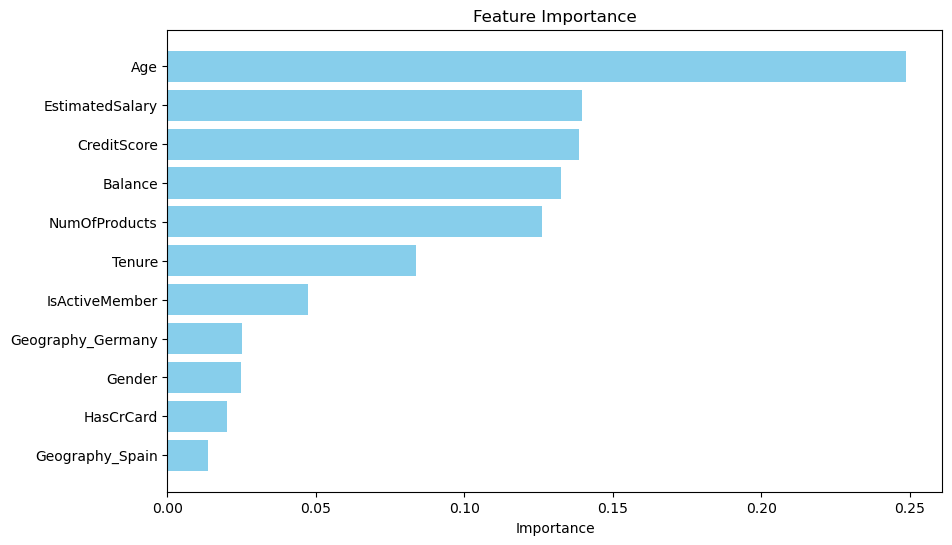

In [14]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

feature_importances = model.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_columns, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()


In [15]:
# Save results including actual, predicted labels, probabilities, and any other relevant columns
results.to_csv('bank_churn_results_final.csv', index=False)

print("Final results exported to 'bank_churn_results_final.csv'")


Final results exported to 'bank_churn_results_final.csv'


Accuracy: 0.825
Actual churn rate: 0.203
Predicted churn rate: 0.218


C:\Users\SUSANTA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


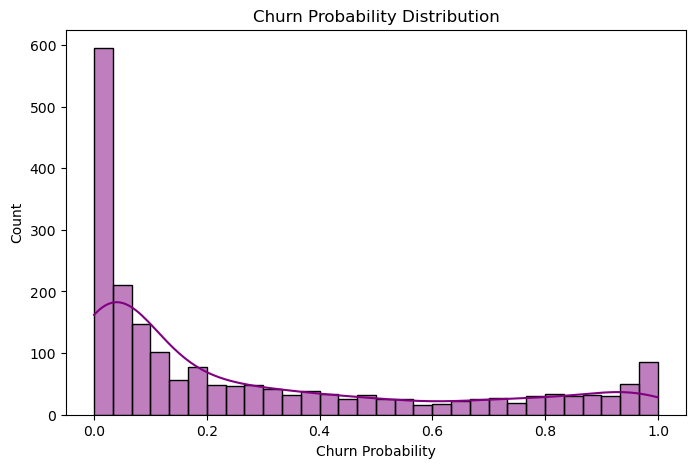

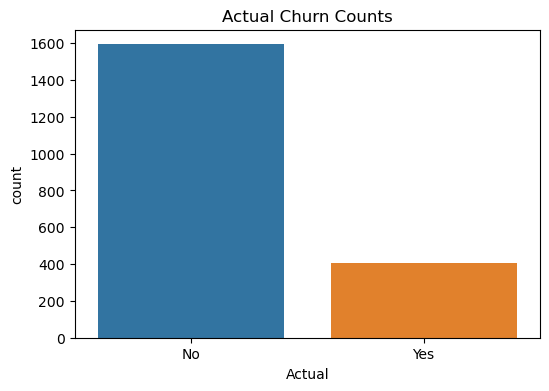

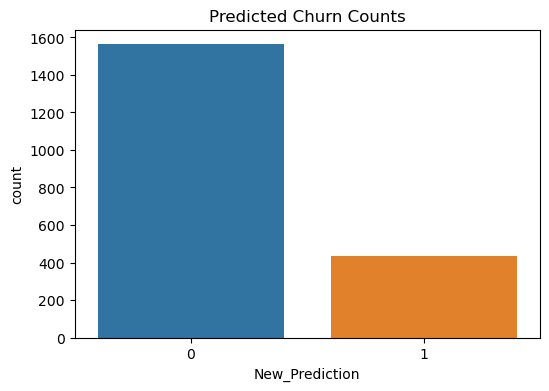

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary metrics
accuracy = (results['Actual_Binary'] == results['New_Prediction']).mean()
churn_rate = results['Actual_Binary'].mean()
predicted_churn_rate = results['New_Prediction'].mean()

print(f"Accuracy: {accuracy:.3f}")
print(f"Actual churn rate: {churn_rate:.3f}")
print(f"Predicted churn rate: {predicted_churn_rate:.3f}")

# Plot churn probability distribution
plt.figure(figsize=(8,5))
sns.histplot(results['Churn_Probability'], bins=30, kde=True, color='purple')
plt.title('Churn Probability Distribution')
plt.xlabel('Churn Probability')
plt.ylabel('Count')
plt.show()

# Bar plot of Actual vs Predicted counts
plt.figure(figsize=(6,4))
sns.countplot(x='Actual', data=results)
plt.title('Actual Churn Counts')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='New_Prediction', data=results)
plt.title('Predicted Churn Counts')
plt.show()


2025-09-24 21:09:52.230 
  command:

    streamlit run C:\Users\SUSANTA\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
C:\Users\SUSANTA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


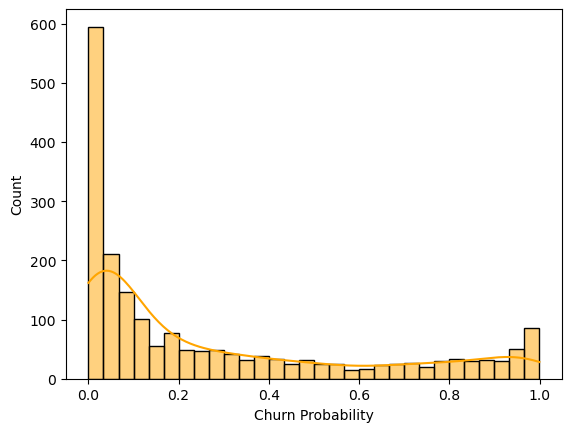

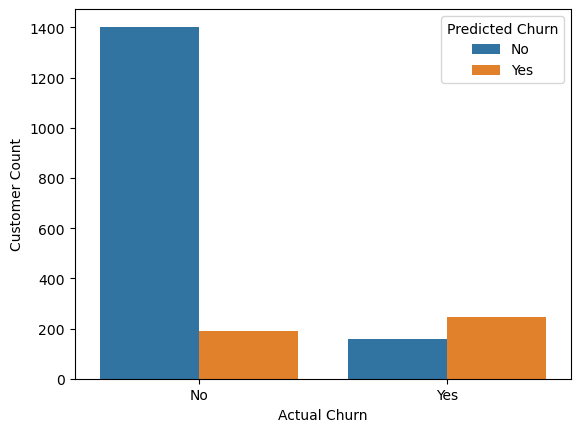

In [2]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your enriched results data
results = pd.read_csv('bank_churn_results_final.csv')

# Convert prediction column to string labels for plotting
results['New_Prediction'] = results['New_Prediction'].map({0: 'No', 1: 'Yes'})

# Sidebar filters
st.sidebar.header('Filter Customers')
churn_filter = st.sidebar.selectbox('Show churned customers?', ['All', 'Yes', 'No'])

if churn_filter != 'All':
    results = results[results['Actual'] == churn_filter]

# Dashboard Title
st.title('Customer Churn Prediction Dashboard')

# Key Metrics
total_customers = len(results)
churned_customers = results['Actual'].value_counts().get('Yes', 0)
predicted_churned = (results['New_Prediction'] == 'Yes').sum()

st.metric('Total Customers', total_customers)
st.metric('Actual Churned Customers', churned_customers)
st.metric('Predicted Churned Customers', predicted_churned)

# Churn Probability Distribution
st.subheader('Churn Probability Distribution')
fig, ax = plt.subplots()
sns.histplot(results['Churn_Probability'], bins=30, kde=True, color='orange', ax=ax)
plt.xlabel('Churn Probability')
plt.ylabel('Count')
st.pyplot(fig)

# Actual vs Predicted Churn Counts
st.subheader('Actual vs Predicted Churn')
fig2, ax2 = plt.subplots()
sns.countplot(x='Actual', hue='New_Prediction', data=results, ax=ax2)
plt.xlabel('Actual Churn')
plt.ylabel('Customer Count')
plt.legend(title='Predicted Churn')
st.pyplot(fig2)

# Feature Importance (optional, load separately if available)
# Example:
# if st.checkbox('Show Feature Importance'):
#     fi_df = pd.read_csv('feature_importance.csv')
#     fig3, ax3 = plt.subplots(figsize=(8,6))
#     sns.barplot(x='Importance', y='Feature', data=fi_df.sort_values(by='Importance', ascending=False), ax=ax3)
#     st.pyplot(fig3)

st.write("Dashboard created with Streamlit.")


In [1]:
import numpy as np

# Replace infinite values and drop NaNs if any
results.replace([np.inf, -np.inf], np.nan, inplace=True)
results.dropna(inplace=True)


NameError: name 'results' is not defined

In [2]:
import pandas as pd

# Load your exported results file
results = pd.read_csv('bank_churn_results.csv')

# Now check the Actual and Predicted value counts
print(results['Actual'].value_counts())
print(results['Predicted'].value_counts())


Actual
0    1593
1     407
Name: count, dtype: int64
Predicted
0    1534
1     466
Name: count, dtype: int64


In [3]:
from sklearn.metrics import classification_report

print(classification_report(results['Actual'], results['Predicted']))


              precision    recall  f1-score   support

           0       0.90      0.87      0.88      1593
           1       0.55      0.62      0.58       407

    accuracy                           0.82      2000
   macro avg       0.72      0.75      0.73      2000
weighted avg       0.83      0.82      0.82      2000



In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_resampled).value_counts())


NameError: name 'X_train' is not defined

2025-10-04 18:39:15.630 
  command:

    streamlit run C:\Users\SUSANTA\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
C:\Users\SUSANTA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


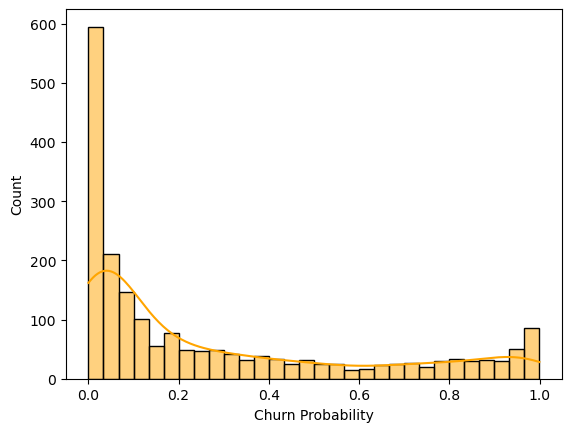

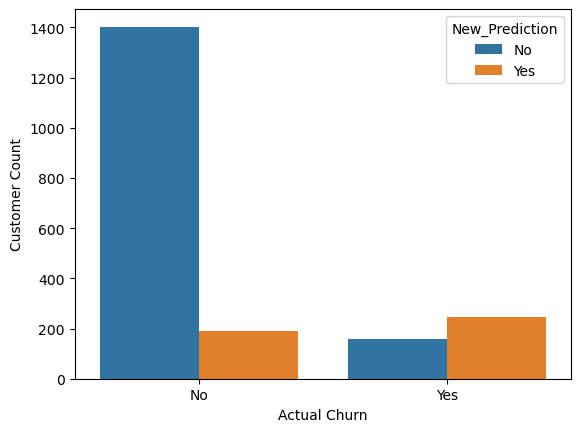

In [6]:
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your churn prediction results
results = pd.read_csv('bank_churn_results_final.csv')

# Map predicted values for display
results['New_Prediction'] = results['New_Prediction'].map({0: 'No', 1: 'Yes'})

# Sidebar filter
st.sidebar.header('Filter Customers')
churn_filter = st.sidebar.selectbox('Show churned customers?', ['All', 'Yes', 'No'])

if churn_filter != 'All':
    results = results[results['Actual'] == churn_filter]

# Dashboard title
st.title('Customer Churn Prediction Dashboard')

# Show key metrics
total_customers = len(results)
churned_customers = results['Actual'].value_counts().get('Yes', 0)
predicted_churned = (results['New_Prediction'] == 'Yes').sum()

st.metric('Total Customers', total_customers)
st.metric('Actual Churned Customers', churned_customers)
st.metric('Predicted Churned Customers', predicted_churned)

# Churn probability distribution plot
st.subheader('Churn Probability Distribution')
fig, ax = plt.subplots()
sns.histplot(results['Churn_Probability'], bins=30, kde=True, color='orange', ax=ax)
plt.xlabel('Churn Probability')
plt.ylabel('Count')
st.pyplot(fig)

# Actual vs Predicted churn counts plot
st.subheader('Actual vs Predicted Churn')
fig2, ax2 = plt.subplots()
sns.countplot(x='Actual', hue='New_Prediction', data=results, ax=ax2)
plt.xlabel('Actual Churn')
plt.ylabel('Customer Count')
st.pyplot(fig2)

st.write("Dashboard created with Streamlit.")
